#**Load & EDA Dataset Recipes Indonesia**

## Pertanyaan Bisnis

1.   Kategori masakan apa yang paling banyak resepnya di Indonesia, dan apakah distribusinya seimbang?
2.   Berapa rata-rata jumlah bahan per resep, dan apakah resep dengan bahan lebih sedikit cenderung lebih populer (loves lebih tinggi)?
3.   Bahan makanan apa yang paling sering muncul di seluruh resep Indonesia?
4.   Apakah resep dengan langkah lebih banyak (lebih kompleks) mendapat engagement (loves) lebih tinggi?







In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORT LIBRARIES
!pip install wordcloud

from wordcloud import WordCloud
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# Setting format visualisasi default yang rapi
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
import pandas as pd

# Ganti string di bawah dengan path yang sudah Anda copy
file_path = '/content/drive/MyDrive/dataset-resep/Indonesian_Food_Recipes.csv'

# Membaca dataset
df = pd.read_csv(file_path)

print(f"Total Baris: {df.shape[0]}, Total Kolom: {df.shape[1]}")

Total Baris: 14945, Total Kolom: 10


In [ ]:
# INITIAL DATA INSPECTION
print("--- 5 Baris Pertama Dataset ---")
print(df.head())

print("\n--- Informasi Tipe Data & Missing Values ---")
df.info()

print("\n--- Ringkasan Statistik Deskriptif (Numerik) ---")
print(df.describe())

print("\n--- Ringkasan Statistik Deskriptif (Kategorikal) ---")
print(df.describe(include=['object']))

--- 5 Baris Pertama Dataset ---
                      Title  \
0          Ayam Woku Manado   
1  Ayam goreng tulang lunak   
2          Ayam cabai kawin   
3               Ayam Geprek   
4               Minyak Ayam   

                                         Ingredients  \
0  1 Ekor Ayam Kampung (potong 12)--2 Buah Jeruk ...   
1  1 kg ayam (dipotong sesuai selera jangan kecil...   
2  1/4 kg ayam--3 buah cabai hijau besar--7 buah ...   
3  250 gr daging ayam (saya pakai fillet)--Secuku...   
4  400 gr kulit ayam & lemaknya--8 siung bawang p...   

                                               Steps  Loves  \
0  1) Cuci bersih ayam dan tiriskan. Lalu peras j...      1   
1  1) Haluskan bumbu2nya (BaPut, ketumbar, kemiri...      1   
2  1) Panaskan minyak di dalam wajan. Setelah min...      2   
3  1) Goreng ayam seperti ayam krispi\n2) Ulek se...     10   
4  1) Cuci bersih kulit ayam. Sisihkan\n2) Ambil ...      4   

                                                 URL Category  \


In [ ]:
# Cek missing values per kolom
print("=== Missing Values ===")
print(df.isnull().sum())

# Cek persentase missing
print("\n=== Persentase Missing ===")
print((df.isnull().sum() / len(df) * 100).round(2))

# Cek duplikat
print("\nJumlah baris duplikat:", df.duplicated().sum())

=== Missing Values ===
Title                   0
Ingredients             0
Steps                   0
Loves                   0
URL                     0
Category                0
Title Cleaned          20
Total Ingredients       0
Ingredients Cleaned     0
Total Steps             0
dtype: int64

=== Persentase Missing ===
Title                  0.00
Ingredients            0.00
Steps                  0.00
Loves                  0.00
URL                    0.00
Category               0.00
Title Cleaned          0.13
Total Ingredients      0.00
Ingredients Cleaned    0.00
Total Steps            0.00
dtype: float64

Jumlah baris duplikat: 0


In [ ]:
# Cek nama kolom

df.columns

Index(['Title', 'Ingredients', 'Steps', 'Loves', 'URL', 'Category',
       'Title Cleaned', 'Total Ingredients', 'Ingredients Cleaned',
       'Total Steps'],
      dtype='object')

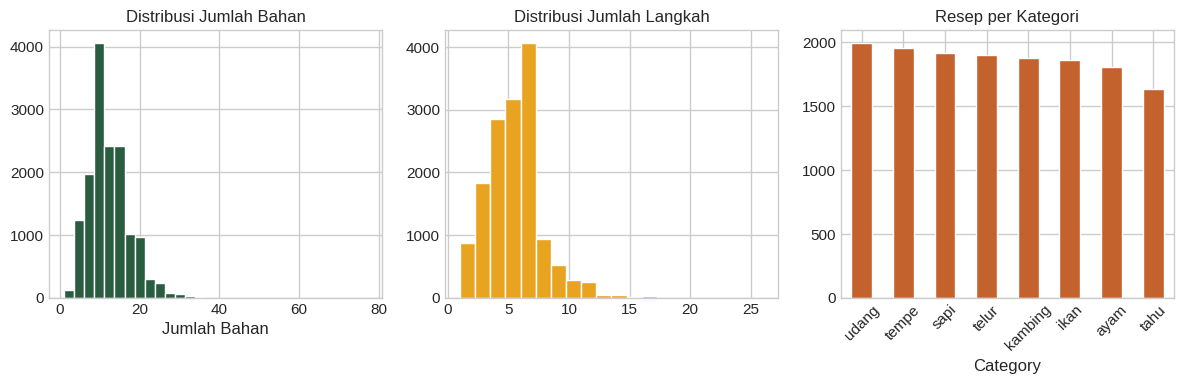

In [ ]:
# Distribusi jumlah bahan per resep

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df['Total Ingredients'].hist(bins=30, color='#2A5C40')
plt.title('Distribusi Jumlah Bahan')
plt.xlabel('Jumlah Bahan')

plt.subplot(1, 3, 2)
df['Total Steps'].hist(bins=20, color='#E8A320')
plt.title('Distribusi Jumlah Langkah')

plt.subplot(1, 3, 3)
df['Category'].value_counts().plot(kind='bar', color='#C4622D')
plt.title('Resep per Kategori')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


#**Cleaning**

In [ ]:
df_clean = df.copy()

# Menghapus baris duplikat berdasarkan judul resep
df_clean = df_clean.drop_duplicates(subset=['Title'])
print(f"Setelah drop duplikat: {len(df_clean)} baris")

# Menghapus baris yang kolom penting-nya kosong
df_clean = df_clean.dropna(subset=['Ingredients', 'Steps'])
print(f"Setelah drop null penting: {len(df_clean)} baris")

# Menghapus baris yang kolom 'Title Cleaned' nya kosong
df_clean = df_clean.dropna(subset=['Title Cleaned'])
print(f"Setelah drop null pada kolom 'Title Cleaned': {len(df_clean)} baris")

Setelah drop duplikat: 12468 baris
Setelah drop null penting: 12468 baris
Setelah drop null pada kolom 'Title Cleaned': 12448 baris


In [ ]:
# Normalisasi teks
# Masalah umum: "Ayam goreng", "ayam goreng", "AYAM GORENG" dianggap berbeda padahal sama. Harus dinormalisasi.

import re

def normalize_text(text):
  if pd.isna(text):
    return ""
  text = str(text).lower().strip() # Lowercase + hapus spasi tepi
  text = re.sub(r'[^\w\s,]', ' ', text) # hapus karakter aneh
  text = re.sub(r'\s+', ' ', text) #normalkan spasi ganda
  return text.strip()


# Terapkan ke kolom yang perlu
df_clean['judul_bersih'] = df_clean['Title'].apply(normalize_text)
df_clean['bahan_bersih'] = df_clean['Ingredients'].apply(normalize_text)

# Cek hasilnya
df_clean[['judul_bersih', 'bahan_bersih']].head(3)

,judul_bersih,bahan_bersih
0,ayam woku manado,1 ekor ayam kampung potong 12 2 buah jeruk nip...
1,ayam goreng tulang lunak,1 kg ayam dipotong sesuai selera jangan kecil2...
2,ayam cabai kawin,1 4 kg ayam 3 buah cabai hijau besar 7 buah ca...


In [ ]:
# Filter berdasarkan kriteria kualitas minimum
MIN_BAHAN = 3 # resep minimal punya 3 bahan
MAX_BAHAN = 25 # resep tidak boleh > 25 bahan (terlalu ribet)
MIN_STEPS = 2 # minimal 2 langkah masak

mask = (
  (df_clean['Total Ingredients'] >= MIN_BAHAN) & # kolom total bahan
  (df_clean['Total Ingredients'] <= MAX_BAHAN) & # kolom total bahan
  (df_clean['Total Steps'] >= MIN_STEPS) # kolom total langkah
)

df_filtered = df_clean[mask].copy()
print(f"Sebelum filter: {len(df_clean)}")
print(f"Sesudah filter: {len(df_filtered)}")

Sebelum filter: 12448
Sesudah filter: 12040


In [ ]:
print(df_filtered['Ingredients Cleaned'][0])

ayam kampung potong , jeruk nipis , garam , kunyit , bawang merah , bawang putih , cabe merah , cabe rawit merah , kemiri , serai , daun salam , daun kemangi , penyedap , air


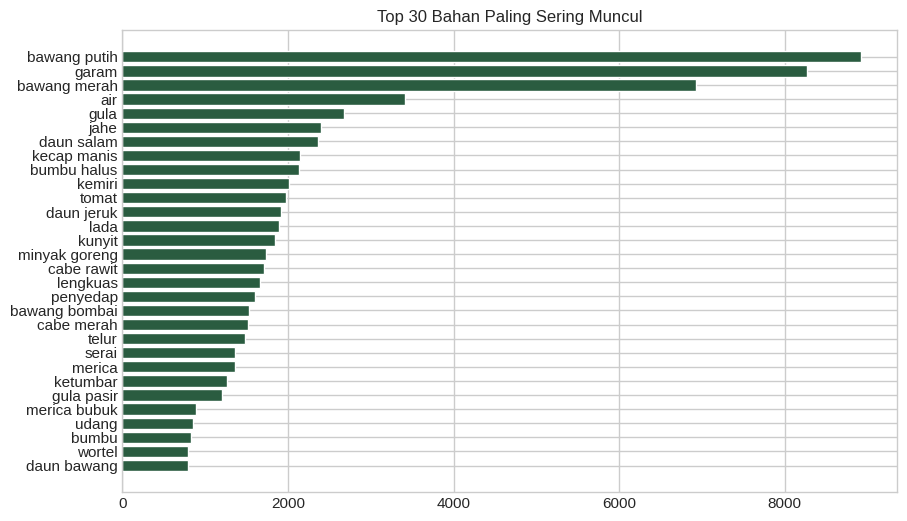

In [ ]:
# Pecah string bahan jadi list, kumpulkan semua
semua_bahan = []

for bahan_str in df_filtered['Ingredients Cleaned'].dropna():
  # Pecah berdasarkan koma, bersihkan spasi
  items = [b.strip() for b in bahan_str.split(',') if b.strip()]
  semua_bahan.extend(items)

# Hitung frekuensi tiap bahan
freq_bahan = Counter(semua_bahan)
top_30 = freq_bahan.most_common(30)

# Visualisasi
names = [x[0] for x in top_30]
counts = [x[1] for x in top_30]

plt.figure(figsize=(10, 6))
plt.barh(names[::-1], counts[::-1], color='#2A5C40')
plt.title('Top 30 Bahan Paling Sering Muncul')
plt.show()

In [ ]:
# Ambil 100 resep terbaik per kategori berdasarkan loves
N_PER_CAT = 625
df_5000 = (
  df_filtered
  .sort_values('Loves', ascending=False) # sort by loves/engagement
  .groupby('Category') # group by kategori
  .head(N_PER_CAT) # ambil top N per group
  .reset_index(drop=True)
)

print(f"Total resep terpilih: {len(df_5000)}")
print("\nDistribusi per kategori:")
print(df_5000['Category'].value_counts())

Total resep terpilih: 5000

Distribusi per kategori:
Category
sapi       625
ikan       625
tahu       625
tempe      625
kambing    625
telur      625
ayam       625
udang      625
Name: count, dtype: int64


In [ ]:
print(df_5000.columns.tolist())
print()
print(df_5000.head(2))

['Title', 'Ingredients', 'Steps', 'Loves', 'URL', 'Category', 'Title Cleaned', 'Total Ingredients', 'Ingredients Cleaned', 'Total Steps', 'judul_bersih', 'bahan_bersih']

                                  Title  \
0            Bakso Sapi (Pakai Blender)   
1  Chilli Tuna Puff Kilat Super Yummy 😙   

                                         Ingredients  \
0  250 gram daging sapi--35 gram es batu (sekitar...   
1  1/2 pack Kulit puff instant saya merk.Edo--Bah...   

                                               Steps  Loves  \
0  1) Siapkan semua bahan, cincang daging sapi ke...    939   
1  1) Langkah \n1.Tumis chili tuna chunk dengan m...    516   

                                                 URL Category  \
0  https://cookpad.com/id/resep/3431604-bakso-sap...     sapi   
1  https://cookpad.com/id/resep/4463240-chilli-tu...     ikan   

                        Title Cleaned  Total Ingredients  \
0        bakso sapi ( pakai blender )                  8   
1  chilli tuna puff kila

In [ ]:
def minmax(series):
  # Ubah nilai ke rentang 0-1
  # min → 0, max → 1, yang lain proporsional
  mn = series.min()
  mx = series.max()

  if mx == mn:
    return pd.Series(0.5, index=series.index)

  return (series - mn) / (mx - mn)

In [ ]:
# Pastikan tipe data numerik
df_5000['Loves'] = pd.to_numeric(df_5000['Loves'], errors='coerce').fillna(0)

# Komponen 1: skor loves (popularitas)
df_5000['skor_loves'] = minmax(df_5000['Loves'])

# Komponen 2: skor panjang teks langkah masak
df_5000['panjang_steps'] = df_5000['Steps'].fillna('').str.len()
df_5000['skor_detail'] = minmax(df_5000['panjang_steps'].clip(50, 2000))
# .clip() batasi nilai ekstrem supaya tidak bias

# Komponen 3: skor jumlah langkah
df_5000['skor_langkah'] = minmax(df_5000['Total Steps'].clip(2, 12))

# Komponen 4: penalti kesederhanaan
# Resep dengan bahan ≤ 12 dapat nilai 1.0 (sempurna)
# Resep > 12 bahan makin turun nilainya
df_5000['skor_simpel'] = df_5000['Total Ingredients'].apply(
  lambda x: 1.0 if x <= 12
  else max(0.3, 1 - (x - 12) * 0.07)
)

In [ ]:
print(df_5000.columns.tolist())

['Title', 'Ingredients', 'Steps', 'Loves', 'URL', 'Category', 'Title Cleaned', 'Total Ingredients', 'Ingredients Cleaned', 'Total Steps', 'judul_bersih', 'bahan_bersih', 'skor_loves', 'panjang_steps', 'skor_detail', 'skor_langkah', 'skor_simpel']


Min: 0.0842
Max: 0.7997
Mean: 0.30000138000000004


<Axes: >

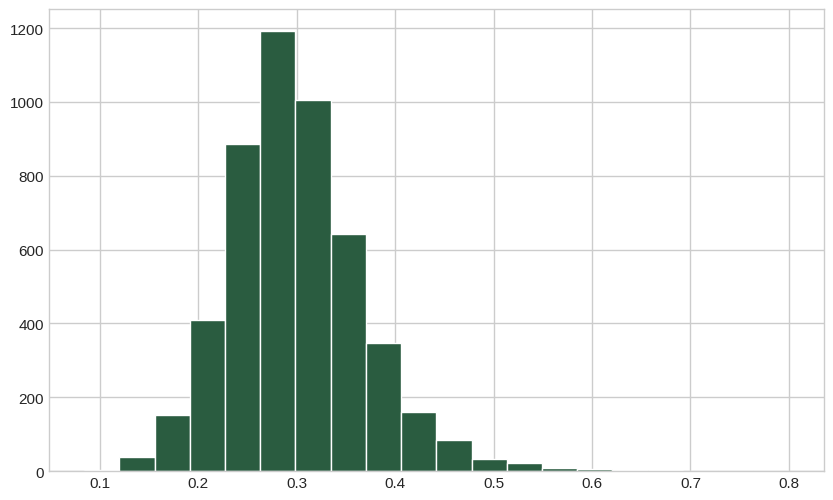

In [ ]:
# Bobot untuk setiap komponen
W_LOVES = 0.35 # popularitas — bobot tertinggi
W_DETAIL = 0.25 # detail instruksi
W_LANGKAH = 0.20 # jumlah langkah
W_SIMPEL = 0.20 # kesederhanaan bahan

# Hitung quality_score
df_5000['Quality Score'] = (
  W_LOVES * df_5000['skor_loves'] +
  W_DETAIL * df_5000['skor_detail'] +
  W_LANGKAH * df_5000['skor_langkah'] +
  W_SIMPEL * df_5000['skor_simpel']
).round(4)

# Cek hasilnya
print("Min:", df_5000['Quality Score'].min())
print("Max:", df_5000['Quality Score'].max())
print("Mean:", df_5000['Quality Score'].mean())
df_5000['Quality Score'].hist(bins=20, color='#2A5C40')

##Jawaban dari Pertanyaan Bisnis

1. Kategori masakan apa yang paling banyak resepnya di Indonesia, dan apakah distribusinya seimbang?

--- Jumlah Resep per Kategori ---
Category
ikan       1733
telur      1703
udang      1617
tempe      1555
sapi       1516
ayam       1514
kambing    1472
tahu       1338
Name: count, dtype: int64


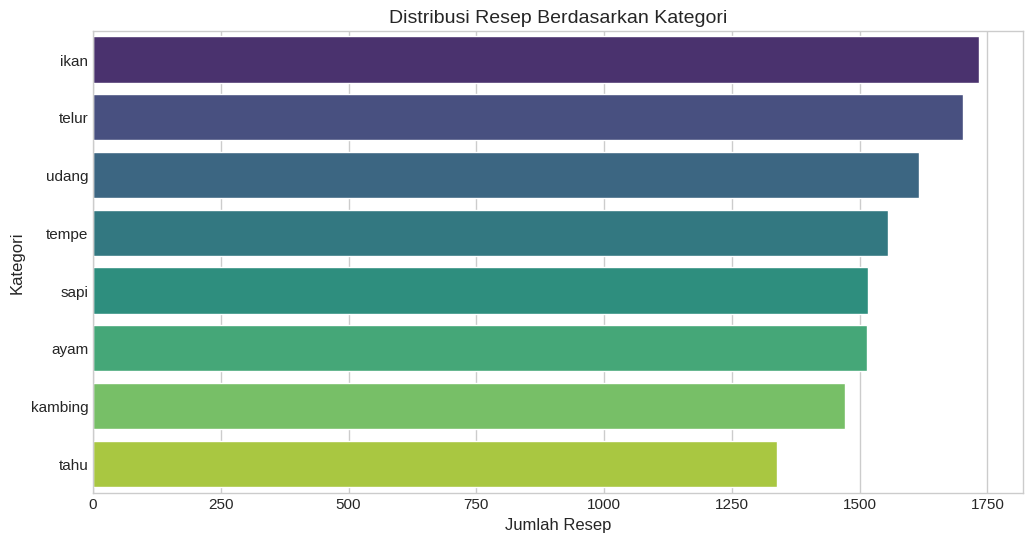

In [ ]:
# Menghitung jumlah resep per kategori
kategori_counts = df_clean['Category'].value_counts()
print("--- Jumlah Resep per Kategori ---")
print(kategori_counts)

# Visualisasi Distribusi Kategori
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, y='Category', order=kategori_counts.index, palette='viridis')
plt.title('Distribusi Resep Berdasarkan Kategori', fontsize=14)
plt.xlabel('Jumlah Resep')
plt.ylabel('Kategori')
plt.show()

2. Berapa rata-rata jumlah bahan per resep, dan apakah resep dengan bahan lebih sedikit cenderung lebih populer?

Rata-rata jumlah bahan per resep: 12.25 bahan


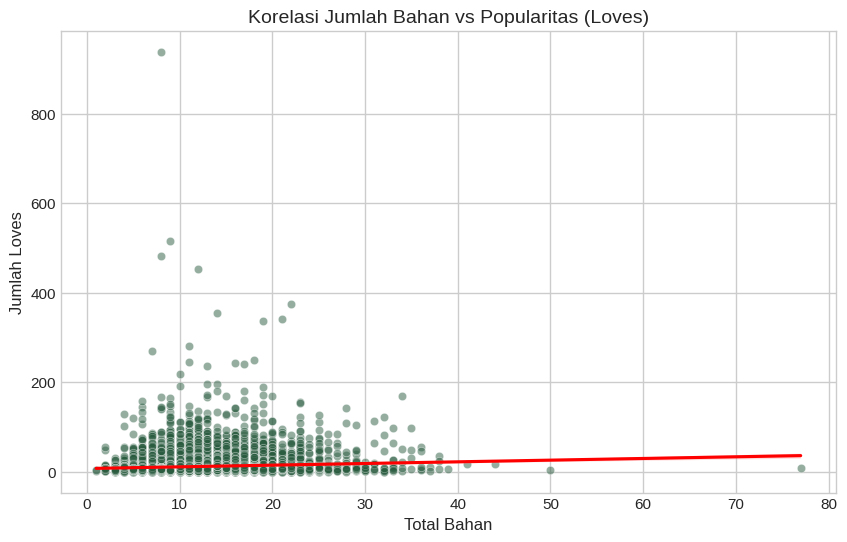

Nilai Korelasi (Bahan vs Loves): 0.0861


In [ ]:
# Menghitung rata-rata jumlah bahan
rata_rata_bahan = df_clean['Total Ingredients'].mean()
print(f"Rata-rata jumlah bahan per resep: {rata_rata_bahan:.2f} bahan")

# Melihat hubungan jumlah bahan vs popularitas (Loves)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Total Ingredients', y='Loves', alpha=0.5, color='#2A5C40')

# Menambahkan garis tren (regresi)
sns.regplot(data=df_clean, x='Total Ingredients', y='Loves', scatter=False, color='red')

plt.title('Korelasi Jumlah Bahan vs Popularitas (Loves)', fontsize=14)
plt.xlabel('Total Bahan')
plt.ylabel('Jumlah Loves')
plt.show()

# Menghitung nilai korelasi Pearson
korelasi_bahan_loves = df_clean['Total Ingredients'].corr(df_clean['Loves'])
print(f"Nilai Korelasi (Bahan vs Loves): {korelasi_bahan_loves:.4f}")

3. Bahan makanan apa yang paling sering muncul di seluruh resep Indonesia?

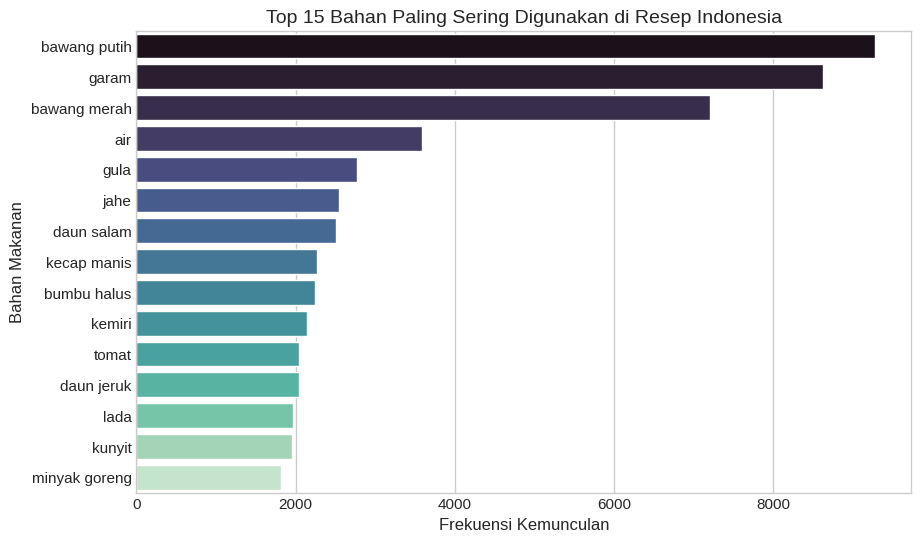

In [ ]:
from collections import Counter

# Gabungkan semua teks bahan menjadi satu list panjang
semua_bahan = []

# Pastikan menggunakan kolom yang sudah dibersihkan, misalnya 'bahan_bersih' atau 'Ingredients Cleaned'
for bahan_str in df_clean['Ingredients Cleaned'].dropna():
    # Asumsi bahan dipisahkan dengan koma
    items = [b.strip() for b in bahan_str.split(',') if b.strip()]
    semua_bahan.extend(items)

# Hitung 15 bahan paling populer
freq_bahan = Counter(semua_bahan)
top_15_bahan = freq_bahan.most_common(15)

# Pisahkan nama bahan dan jumlahnya untuk plot
nama_bahan = [x[0] for x in top_15_bahan]
jumlah_bahan = [x[1] for x in top_15_bahan]

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(x=jumlah_bahan, y=nama_bahan, palette='mako')
plt.title('Top 15 Bahan Paling Sering Digunakan di Resep Indonesia', fontsize=14)
plt.xlabel('Frekuensi Kemunculan')
plt.ylabel('Bahan Makanan')
plt.show()

4. Apakah resep dengan langkah lebih banyak (lebih kompleks) mendapat engagement (loves) lebih tinggi?

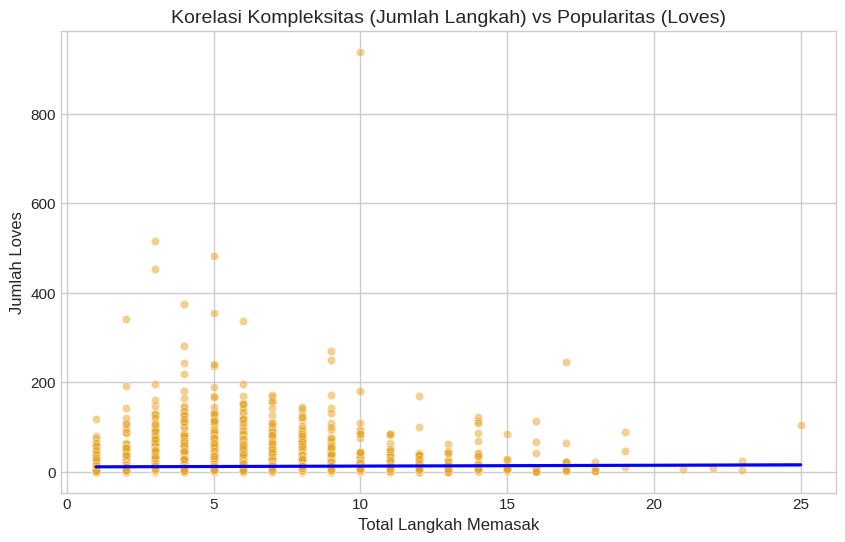

Nilai Korelasi (Langkah vs Loves): 0.0195


In [ ]:
# Melihat hubungan jumlah langkah (Total Steps) vs popularitas (Loves)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Total Steps', y='Loves', alpha=0.5, color='#E8A320')

# Menambahkan garis tren
sns.regplot(data=df_clean, x='Total Steps', y='Loves', scatter=False, color='blue')

plt.title('Korelasi Kompleksitas (Jumlah Langkah) vs Popularitas (Loves)', fontsize=14)
plt.xlabel('Total Langkah Memasak')
plt.ylabel('Jumlah Loves')
plt.show()

# Menghitung nilai korelasi Pearson
korelasi_langkah_loves = df_clean['Total Steps'].corr(df_clean['Loves'])
print(f"Nilai Korelasi (Langkah vs Loves): {korelasi_langkah_loves:.4f}")

In [ ]:
# Hapus kolom sementara
kolom_hapus = ['skor_loves', 'skor_detail',
               'skor_langkah', 'skor_simpel', 'panjang_steps']
df_5000 = df_5000.drop(columns=kolom_hapus, errors='ignore')
# errors='ignore' → tidak error walau kolom tidak ada

# Cek kolom final
print("Kolom final:", df_5000.columns.tolist())
print("Jumlah resep:", len(df_5000))

# Simpan ke CSV
df_5000.to_csv('clean_recipes_5000_with_score.csv', index=False)

# Export ke JSON
import json
with open('clean_recipes_5000.json', 'w', encoding='utf-8') as f:
  json.dump(df_5000.to_dict('records'), f,
           ensure_ascii=False, indent=2)
print("Selesai!")